In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
spam = pd.read_csv("spam_results.csv")
elec = pd.read_csv("electricity_results.csv")
college = pd.read_csv("college_results.csv")
employee = pd.read_csv("employee_results.csv")

In [5]:
df = pd.concat([spam, elec, college, employee], ignore_index=True)
df = df.drop('Unnamed: 0', axis=1)
print(df.head())

      method dataset missing_schema  accuracy  balanced_accuracy  f1_score  \
0     Oracle    Spam           MCAR  0.914224           0.907551  0.889510   
1      Naive    Spam           MCAR  0.919653           0.913956  0.896936   
2   KNN_hard    Spam           MCAR  0.912052           0.904314  0.886076   
3  KNN_proba    Spam           MCAR  0.915309           0.907003  0.889831   
4         EM    Spam           MCAR  0.920738           0.914852  0.898187   

    roc_auc  missing_rate  fold  n_neighbors  
0  0.966053           0.1     0          NaN  
1  0.967075           0.1     0          NaN  
2  0.966068           0.1     0          5.0  
3  0.965975           0.1     0          5.0  
4  0.966883           0.1     0          NaN  


In [94]:
summary = df.groupby(["dataset", "method", "missing_schema", "missing_rate"]).agg({
    "accuracy": "mean",
    "balanced_accuracy": "mean",
    "f1_score": "mean",
    "roc_auc": "mean"
}).reset_index()

print(summary)

     dataset  method missing_schema  missing_rate  accuracy  \
0    College      EM           MAR1           0.1  0.930388   
1    College      EM           MAR1           0.3  0.928303   
2    College      EM           MAR1           0.5  0.926057   
3    College      EM           MAR1           0.8  0.901995   
4    College      EM           MAR2           0.1  0.929746   
..       ...     ...            ...           ...       ...   
315     Spam  Oracle           MCAR           0.8  0.920019   
316     Spam  Oracle           MNAR           0.1  0.920019   
317     Spam  Oracle           MNAR           0.3  0.920019   
318     Spam  Oracle           MNAR           0.5  0.920019   
319     Spam  Oracle           MNAR           0.8  0.920019   

     balanced_accuracy  f1_score   roc_auc  
0             0.808670  0.702447  0.957191  
1             0.806401  0.695553  0.956079  
2             0.788735  0.675619  0.951705  
3             0.667546  0.442023  0.837106  
4             0.81

In [97]:
oracle_results = df.groupby(["method", "dataset"]).agg({
    "accuracy": "mean",
    "balanced_accuracy": "mean",
    "f1_score": "mean",
    "roc_auc": "mean"
}).reset_index()
oracle_results = oracle_results[oracle_results["method"] == "Oracle"]
print(oracle_results)

    method      dataset  accuracy  balanced_accuracy  f1_score   roc_auc
16  Oracle      College  0.930388           0.812966  0.705820  0.957384
17  Oracle  Electricity  0.755583           0.735427  0.676444  0.818916
18  Oracle     Employee  0.985661           0.500000  0.992779  0.686068
19  Oracle         Spam  0.920019           0.912191  0.896017  0.969251


In [10]:
methods_results = df.groupby(["method", "missing_schema", "missing_rate"]).agg({
    "accuracy": "mean",
    "balanced_accuracy": "mean",
    "f1_score": "mean",
    "roc_auc": "mean"
}).reset_index()

print(methods_results)

    method missing_schema  missing_rate  accuracy  balanced_accuracy  \
0       EM           MAR1           0.1  0.897352           0.738271   
1       EM           MAR1           0.3  0.894571           0.735295   
2       EM           MAR1           0.5  0.892149           0.728418   
3       EM           MAR1           0.8  0.863189           0.667841   
4       EM           MAR2           0.1  0.898306           0.740136   
..     ...            ...           ...       ...                ...   
75  Oracle           MCAR           0.8  0.897913           0.740146   
76  Oracle           MNAR           0.1  0.897913           0.740146   
77  Oracle           MNAR           0.3  0.897913           0.740146   
78  Oracle           MNAR           0.5  0.897913           0.740146   
79  Oracle           MNAR           0.8  0.897913           0.740146   

    f1_score   roc_auc  
0   0.815973  0.857413  
1   0.811362  0.852978  
2   0.803677  0.850846  
3   0.668190  0.802925  
4   0.8175

### The employee dataset is excluded from further analyses
The employee dataset is extremely unbalanced, with 33958 instances of class 1 and 494 instances of class 0. For all experiments conducted for this dataset, the balanced accuracy value is equal to 0.5 (or 0.499926 in one case), while the accuracy metric is almost 1. This shows that in all experiments on this dataset, the produced model was only predicting the majority class. Thefore all examined approached did not handle this extremely unbalanced problem.

In [52]:
df[df["dataset"] == "Employee"]["balanced_accuracy"].value_counts()

0.500000    399
0.499926      1
Name: balanced_accuracy, dtype: int64

### Analyses of the remaining datasets

    dataset missing_schema  missing_rate  accuracy  balanced_accuracy  \
0   College           MAR1           0.1  0.930372           0.810003   
1   College           MAR1           0.3  0.929057           0.808390   
2   College           MAR1           0.5  0.927773           0.797989   
3   College           MAR1           0.8  0.907737           0.690491   
4   College           MAR2           0.1  0.929842           0.811257   
..      ...            ...           ...       ...                ...   
59     Spam           MCAR           0.8  0.898806           0.887229   
60     Spam           MNAR           0.1  0.918671           0.910312   
61     Spam           MNAR           0.3  0.917019           0.908022   
62     Spam           MNAR           0.5  0.912368           0.901331   
63     Spam           MNAR           0.8  0.872726           0.851275   

    f1_score   roc_auc  
0   0.703279  0.957305  
1   0.698910  0.956431  
2   0.687398  0.953494  
3   0.486523  0.905422 

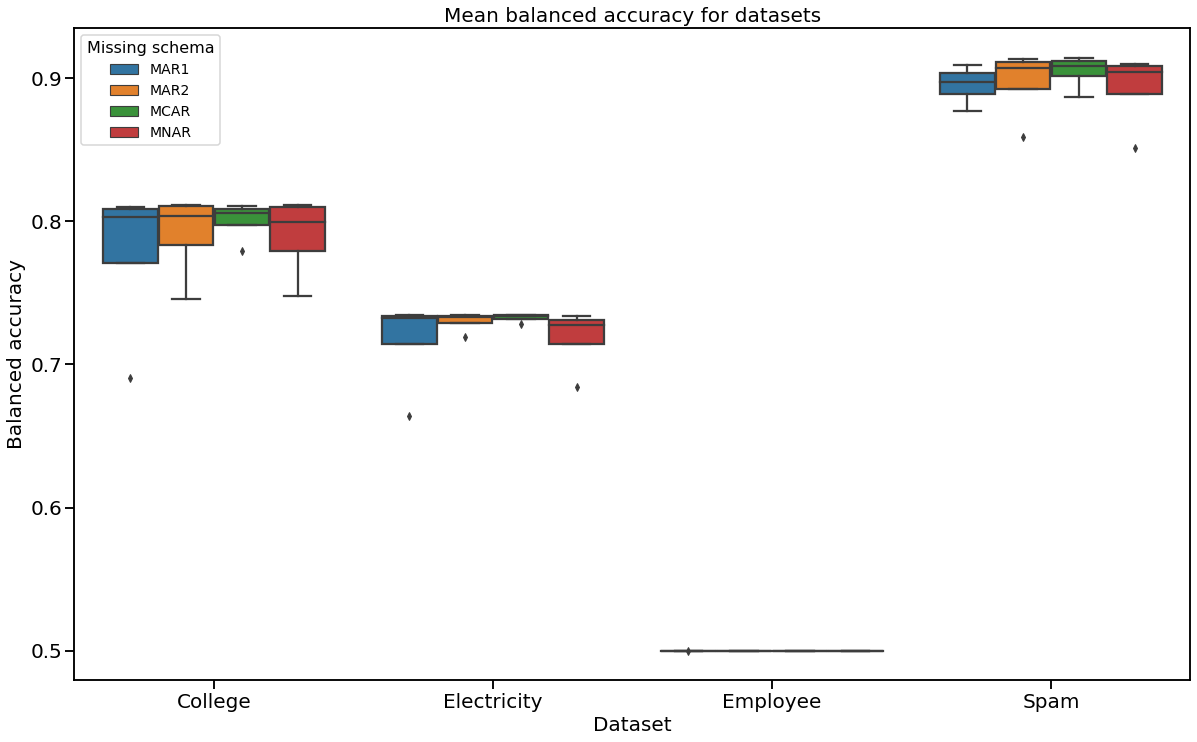

In [93]:
datasets_results = df.groupby(["dataset", "missing_schema", "missing_rate"]).agg({
    "accuracy": "mean",
    "balanced_accuracy": "mean",
    "f1_score": "mean",
    "roc_auc": "mean"
}).reset_index()


print(datasets_results)

plt.figure(figsize=(20,12))

ax = sns.boxplot(
    data=datasets_results,
    x="dataset",
    y="balanced_accuracy",
    hue="missing_schema"
)

ax.set_title("Mean balanced accuracy for datasets", fontsize=20)
ax.set_xlabel("Dataset", fontsize=20)
ax.set_ylabel("Balanced accuracy", fontsize=20)

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

plt.legend(title="Missing schema", fontsize=14, title_fontsize=16)

plt.show()

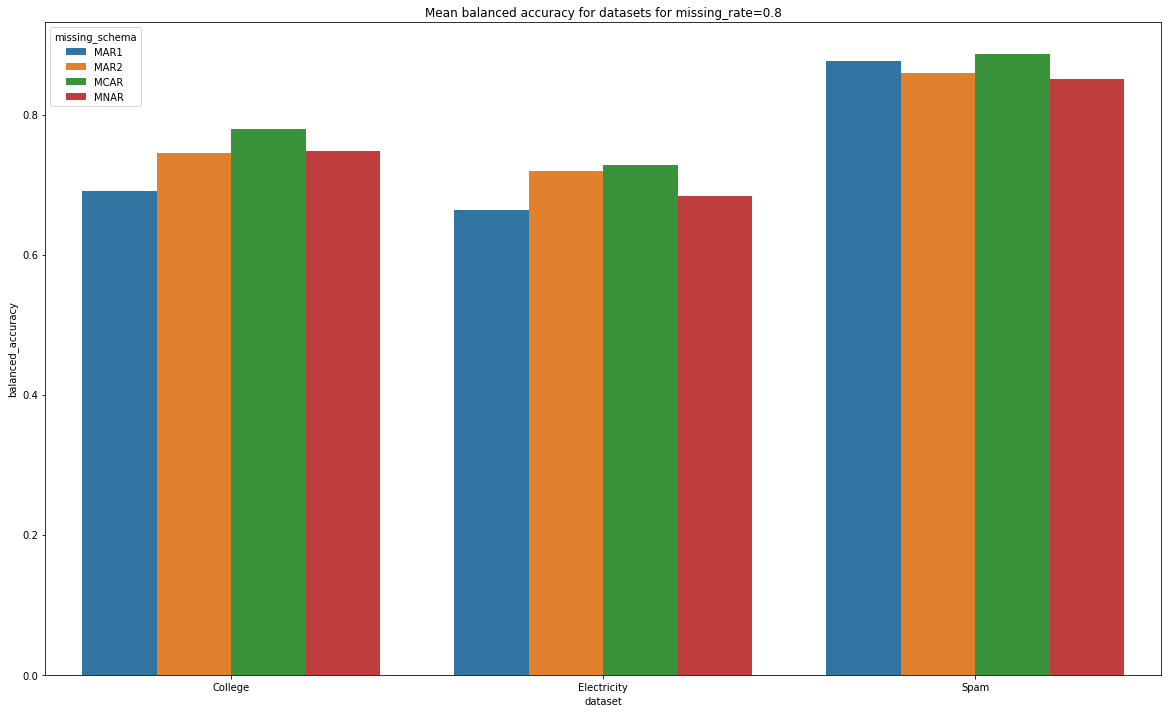

In [57]:
df_08 = df[df["missing_rate"] == 0.8]

datasets_results = df_08.groupby(["dataset", "missing_schema", "missing_rate"]).agg({
    "accuracy": "mean",
    "balanced_accuracy": "mean",
    "f1_score": "mean",
    "roc_auc": "mean"
}).reset_index()

plt.figure(figsize=(20,12))
sns.barplot(
        data= datasets_results[datasets_results["dataset"] != "Employee"],
        x="dataset",
        y="balanced_accuracy",
        hue="missing_schema"
    )
plt.title("Mean balanced accuracy for datasets for missing_rate=0.8")
plt.show()

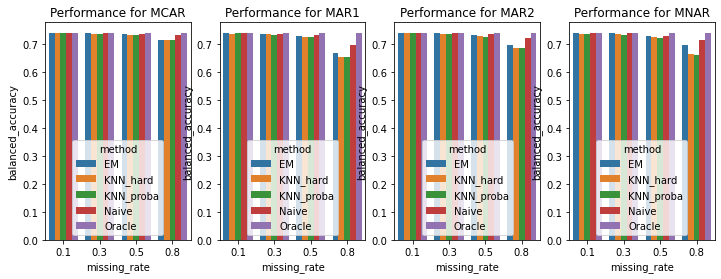

In [18]:
missing_schemas = ["MCAR", "MAR1", "MAR2", "MNAR"]
plt.figure(figsize = (12,4))
i=1

for schema in missing_schemas:
    schema_data = methods_results[methods_results["missing_schema"] == schema]
    plt.subplot(1,4,i)
    sns.boxplot(
        data= schema_data,
        x="missing_rate",
        y="balanced_accuracy",
        hue="method"
    )
    plt.title(f"Mean balanced accuracy for {schema}")
    i+=1
    
plt.show()

<Figure size 1800x1080 with 0 Axes>

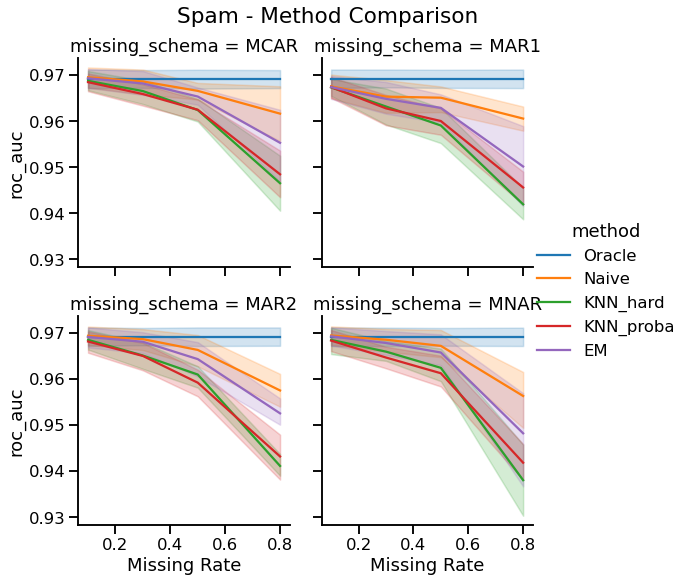

In [87]:
def compare_methods_per_dataset(df, dataset_name, metric="roc_auc"):
    data = df[df["dataset"] == dataset_name]
    plt.figure(figsize=(25,15))
    g = sns.FacetGrid(data, col="missing_schema", hue="method", col_wrap=2, height=4)
    g.map(sns.lineplot, "missing_rate", metric)
    g.add_legend()
    
    g.set_axis_labels("Missing Rate", metric)
    g.fig.suptitle(f"{dataset_name} - Method Comparison", y=1.02)
    
    plt.show()

compare_methods_per_dataset(df, "Spam")

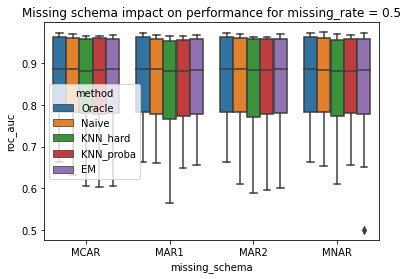

In [32]:
sns.boxplot(
    data=df[df["missing_rate"] == 0.5],
    x="missing_schema",
    y="roc_auc",
    hue="method"
)
plt.title("Missing schema impact on performance for missing_rate = 0.5")
plt.show()

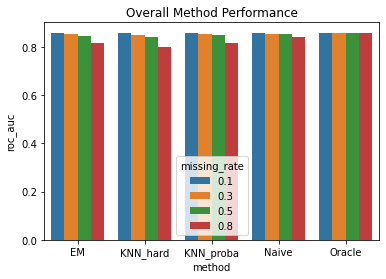

In [36]:
global_perf = df.groupby(["method", "missing_rate"])["roc_auc"].mean().reset_index()

sns.barplot(data=global_perf, x="method", y="roc_auc", hue="missing_rate")
plt.title("Overall Method Performance")
plt.show()

In [40]:
ranking = df.groupby(
    ["dataset", "missing_schema", "missing_rate", "method"]
)["roc_auc"].mean().reset_index()

ranking["rank"] = ranking.groupby(
    ["dataset", "missing_schema", "missing_rate"]
)["roc_auc"].rank(ascending=False)

print(ranking)

     dataset missing_schema  missing_rate     method   roc_auc  rank
0    College           MAR1           0.1         EM  0.957191   5.0
1    College           MAR1           0.1   KNN_hard  0.957311   3.0
2    College           MAR1           0.1  KNN_proba  0.957445   1.0
3    College           MAR1           0.1      Naive  0.957196   4.0
4    College           MAR1           0.1     Oracle  0.957384   2.0
..       ...            ...           ...        ...       ...   ...
315     Spam           MNAR           0.8         EM  0.948244   3.0
316     Spam           MNAR           0.8   KNN_hard  0.938060   5.0
317     Spam           MNAR           0.8  KNN_proba  0.941858   4.0
318     Spam           MNAR           0.8      Naive  0.956355   2.0
319     Spam           MNAR           0.8     Oracle  0.969251   1.0

[320 rows x 6 columns]


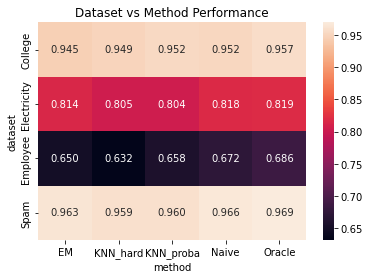

In [58]:
heatmap_data = df.groupby(
    ["dataset", "method"]
)["roc_auc"].mean().unstack()

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Dataset vs Method Performance")
plt.show()

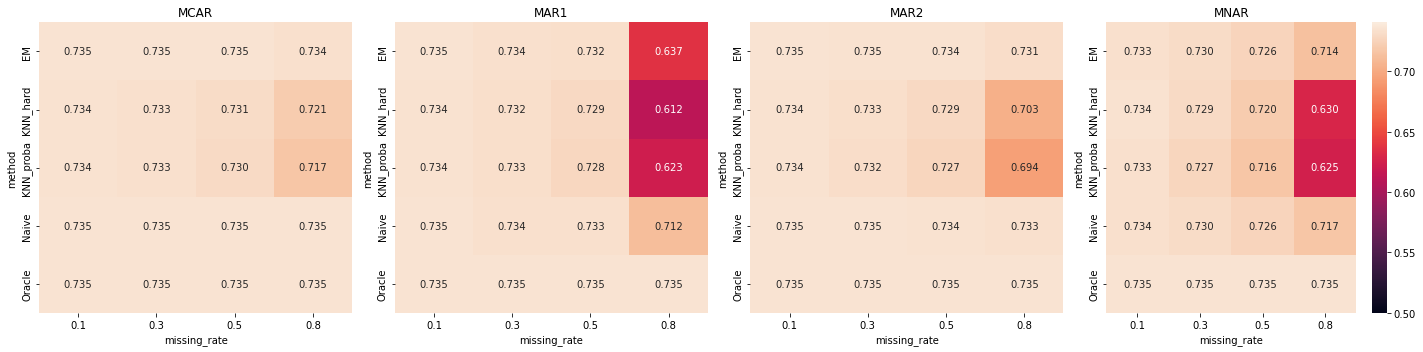

In [64]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

vmin = elec["balanced_accuracy"].min()
vmax = elec["balanced_accuracy"].max()

for i, schema in enumerate(missing_schemas):
    d = elec[elec["missing_schema"] == schema]
    
    heatmap_data = d.groupby(
        ["method", "missing_rate"]
    )["balanced_accuracy"].mean().unstack()
    
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        vmin=vmin,
        vmax=vmax,
        cbar=(i == len(missing_schemas) - 1), 
        ax=axes[i]
    )
    
    axes[i].set_title(f"{schema}")

plt.tight_layout()
plt.show()

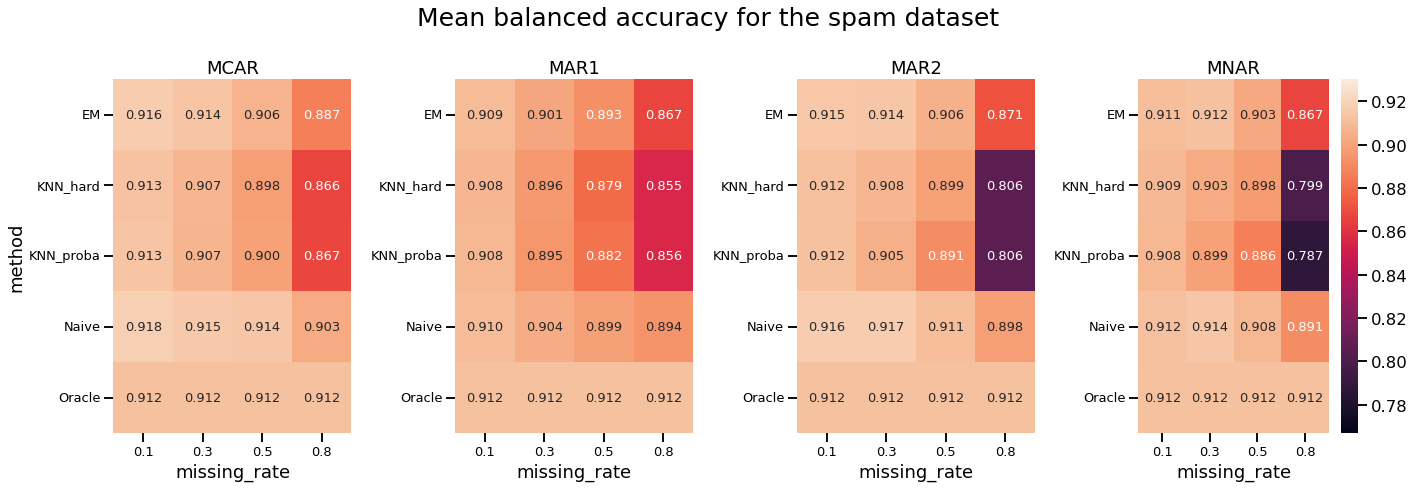

In [86]:
sns.set_context("talk", font_scale=1)

fig, axes = plt.subplots(1, 4, figsize=(20, 7))

vmin = spam["balanced_accuracy"].min()
vmax = spam["balanced_accuracy"].max()

for i, schema in enumerate(missing_schemas):
    d = spam[spam["missing_schema"] == schema]
    
    heatmap_data = d.groupby(
        ["method", "missing_rate"]
    )["balanced_accuracy"].mean().unstack()
    
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        annot_kws={"size": 13},
        vmin=vmin,
        vmax=vmax,
        cbar=(i == len(missing_schemas) - 1), 
        ax=axes[i]
    )
    
    axes[i].set_title(f"{schema}")
    if i != 0:
        axes[i].set_ylabel("")
    axes[i].tick_params(axis='both', labelsize=13)
fig.suptitle("Mean balanced accuracy for the spam dataset", fontsize=25)
plt.tight_layout()
plt.show()

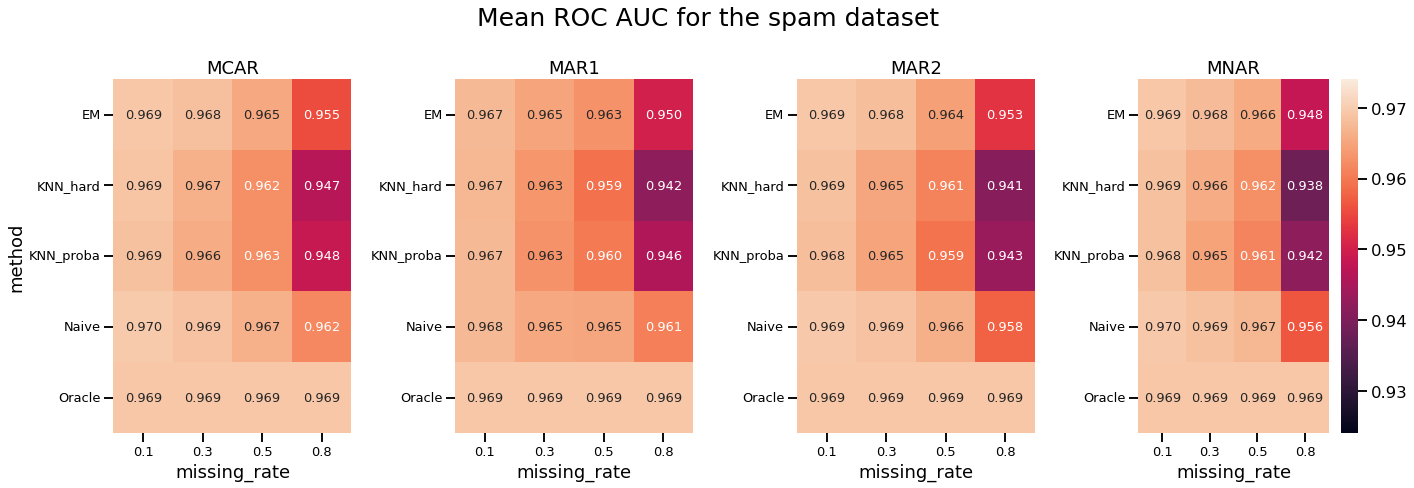

In [98]:
sns.set_context("talk", font_scale=1)

fig, axes = plt.subplots(1, 4, figsize=(20, 7))

vmin = spam["roc_auc"].min()
vmax = spam["roc_auc"].max()

for i, schema in enumerate(missing_schemas):
    d = spam[spam["missing_schema"] == schema]
    
    heatmap_data = d.groupby(
        ["method", "missing_rate"]
    )["roc_auc"].mean().unstack()
    
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        annot_kws={"size": 13},
        vmin=vmin,
        vmax=vmax,
        cbar=(i == len(missing_schemas) - 1), 
        ax=axes[i]
    )
    
    axes[i].set_title(f"{schema}")
    if i != 0:
        axes[i].set_ylabel("")
    axes[i].tick_params(axis='both', labelsize=13)
fig.suptitle("Mean ROC AUC for the spam dataset", fontsize=25)
plt.tight_layout()
plt.show()

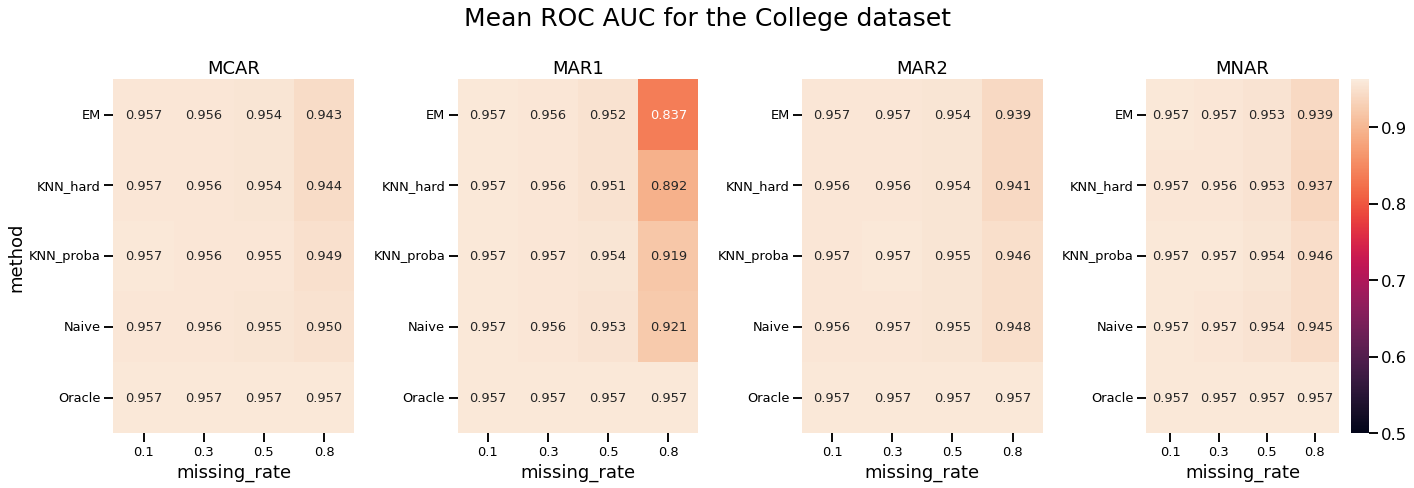

In [101]:
sns.set_context("talk", font_scale=1)

fig, axes = plt.subplots(1, 4, figsize=(20, 7))

vmin = college["roc_auc"].min()
vmax = college["roc_auc"].max()

for i, schema in enumerate(missing_schemas):
    d = college[college["missing_schema"] == schema]
    
    heatmap_data = d.groupby(
        ["method", "missing_rate"]
    )["roc_auc"].mean().unstack()
    
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        annot_kws={"size": 13},
        vmin=vmin,
        vmax=vmax,
        cbar=(i == len(missing_schemas) - 1), 
        ax=axes[i]
    )
    
    axes[i].set_title(f"{schema}")
    if i != 0:
        axes[i].set_ylabel("")
    axes[i].tick_params(axis='both', labelsize=13)
fig.suptitle("Mean ROC AUC for the College dataset", fontsize=25)
plt.tight_layout()
plt.show()